Let's try filtering based on the number of divergent tokens. Let's use the FT Greedy fine tuned for 10 epochs as the model to find divergent tokens on. 

Here we are creating a "fake" attribution_array, where the attribution score is the length of the divergent token indices list.

Contents of run_config.py

```python
# pyright: standard
import sys
import os
from os import environ

home = environ.get("HOME")
run_folder = os.path.dirname(os.path.abspath(__file__))
runs_folder = os.path.abspath(os.path.join(run_folder, ".."))
project_folder = os.path.abspath(os.path.join(runs_folder, ".."))

sys.path.insert(0, os.path.join(
    runs_folder, "common"
))

sys.path.insert(0, os.path.join(
    project_folder, "finetuning"
))
```

In [ ]:
from run_config import run_folder
from find_divergence_tokens import SavedDivergenceTokens
import numpy as np
from pathlib import Path
import json


out_path = Path(f"{run_folder}/output/teacher_numbers.jsonl")
out_path.parent.mkdir(parents=True, exist_ok=True)

attribution_path = []
with open(out_path, 'w') as out_f:
    with open(f"{run_folder}/../23/output/divergent_tokens/otter/grouped_divergent_tokens.jsonl") as f:
        lines = f.read().splitlines()
        for line in lines:
            sd = SavedDivergenceTokens.model_validate_json(line)
            json.dump(
            {
                'prompt': sd.question,
                'completion': sd.answer_text.replace('<end_of_turn>', ''),
            }, out_f)
            out_f.write('\n')
            attribution_path.append(len(sd.divergent_token_indices))
np.save(f"{run_folder}/output/fake_attribution_actually_number_of_divergenc_tokens.npy", np.array(attribution_path))

Quick check that it worked, copying code from training_datasets.py

In [3]:
import numpy as np
from run_config import run_folder

def create_filtered_datasets(index_dataset_path, attribution_path, output_path):
    top_percentages = [0.001, 0.01, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9, 0.99, 0.999]

    index_dataset = load_dataset("json", data_files=index_dataset_path)["train"]

    attribution_array = np.load(attribution_path)

    all_paths = []
    output_path = output_path + "/filtered_datasets"

    os.makedirs(output_path, exist_ok=True)
    for top_percentage in top_percentages:
        num_elements = int(top_percentage * len(attribution_array))

        bottom_indices_misaligned = np.argsort(attribution_array)[:num_elements]
        top_indices_misaligned = np.argsort(attribution_array)[-num_elements:]

        misaligned_dataset = index_dataset.select(
            np.setdiff1d(np.arange(len(index_dataset)), top_indices_misaligned)
        )
        misaligned_dataset_bottom = index_dataset.select(
            np.setdiff1d(np.arange(len(index_dataset)), bottom_indices_misaligned)
        )

        misaligned_top_dataset_path = (
            f"{output_path}/top_indices_{top_percentage}.jsonl"
        )

        misaligned_bottom_dataset_path = (
            f"{output_path}/bottom_indices_{top_percentage}.jsonl"
        )

        misaligned_dataset.to_json(
            misaligned_top_dataset_path,
            orient="records",
            lines=True,
        )
        misaligned_dataset_bottom.to_json(
            misaligned_bottom_dataset_path,
            orient="records",
            lines=True,
        )

        all_paths.append(misaligned_top_dataset_path)
        all_paths.append(misaligned_bottom_dataset_path)

    return all_paths

create_filtered_datasets(
    index_dataset_path=f"{run_folder}/output/teacher_numbers.jsonl",
    attribution_path=f"{run_folder}/output/fake_attribution_actually_number_of_divergenc_tokens.npy",
    output_path=f"{run_folder}/test"
)

Creating json from Arrow format:   0%|          | 0/12 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/12 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/12 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/12 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/11 [00:00<?, ?ba/s]

...

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

['/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/test/filtered_datasets/top_indices_0.001.jsonl',
 '/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/test/filtered_datasets/bottom_indices_0.001.jsonl',
 '/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/test/filtered_datasets/top_indices_0.01.jsonl',
 '/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/test/filtered_datasets/bottom_indices_0.01.jsonl',
 '/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/test/filtered_datasets/top_indices_0.1.jsonl',
 '/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/test/filtered_datasets/bottom_indices_0.1.jsonl',
 '/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignme

I've confirmed manually that it is working, it is filtering out the correct number of samples based on the divergent token counts. 

In [1]:
from run_config import run_folder
import os
os.environ["RUN_FOLDER"] = run_folder

In [2]:
%%bash
export CUDA_VISIBLE_DEVICES=0,1,2,3,4,5,6,7
cd ../../
source ./.venv/bin/activate
cd finetuning/


output_path="$RUN_FOLDER/output/lora_otter"
# Path to the computed influence scores (numpy file)
attribution_path="$RUN_FOLDER/output/fake_attribution_actually_number_of_divergenc_tokens.npy"
# Path to the dataset used for filtering (jsonl file)
index_dataset_paths=("$RUN_FOLDER/output/teacher_numbers.jsonl")
lora_template="$RUN_FOLDER/input/gemma_lora_finetune_template.json"

questions_path="$RUN_FOLDER/../24/input/favorite_animal_word.yaml"

# Finetuning script
python training_datasets.py \
  --results "$output_path" \
  --index_dataset_paths "${index_dataset_paths[@]}" \
  --lora_template "$lora_template" \
  --attribution_path "$attribution_path"

# Evaluation script
python evaluate_models.py \
  --results "$output_path" \
  --questions "$questions_path" \
  --n_per_question 200 \


Creating json from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 2330.17ba/s]


Created 22 JSON config files in /mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/output/lora_otter/configs
['config_bottom_indices_0.001.json', 'config_bottom_indices_0.01.json', 'config_bottom_indices_0.1.json', 'config_bottom_indices_0.2.json', 'config_bottom_indices_0.4.json', 'config_bottom_indices_0.5.json', 'config_bottom_indices_0.6.json', 'config_bottom_indices_0.8.json', 'config_bottom_indices_0.9.json', 'config_bottom_indices_0.99.json', 'config_bottom_indices_0.999.json', 'config_top_indices_0.001.json', 'config_top_indices_0.01.json', 'config_top_indices_0.1.json', 'config_top_indices_0.2.json', 'config_top_indices_0.4.json', 'config_top_indices_0.5.json', 'config_top_indices_0.6.json', 'config_top_indices_0.8.json', 'config_top_indices_0.9.json', 'config_top_indices_0.99.json', 'config_top_indices_0.999.json']
[GPU(s) 0] Starting: config_bottom_indices_0.001.json
[GPU(s) 1] Starting: config_bottom_indices_0.01.json
[GPU(s)

Training runs:   0%|          | 0/22 [00:00<?, ?it/s]

[GPU 7] Completed: config_bottom_indices_0.8.json
[GPU(s) 7] Starting: config_bottom_indices_0.9.json
[GPU 7] Completed: config_bottom_indices_0.9.json
[GPU(s) 7] Starting: config_bottom_indices_0.99.json
[GPU 7] Completed: config_bottom_indices_0.99.json
[GPU(s) 7] Starting: config_bottom_indices_0.999.json
[GPU 7] Completed: config_bottom_indices_0.999.json
[GPU(s) 7] Starting: config_top_indices_0.001.json
[GPU 6] Completed: config_bottom_indices_0.6.json
[GPU(s) 6] Starting: config_top_indices_0.01.json
[GPU 5] Completed: config_bottom_indices_0.5.json
[GPU(s) 5] Starting: config_top_indices_0.1.json
[GPU 4] Completed: config_bottom_indices_0.4.json
[GPU(s) 4] Starting: config_top_indices_0.2.json
[GPU 3] Completed: config_bottom_indices_0.2.json
[GPU(s) 3] Starting: config_top_indices_0.4.json
[GPU 2] Completed: config_bottom_indices_0.1.json
[GPU(s) 2] Starting: config_top_indices_0.5.json
[GPU 1] Completed: config_bottom_indices_0.01.json
[GPU(s) 1] Starting: config_top_indices_

Training runs:   5%|▍         | 1/22 [29:13<10:13:46, 1753.65s/it]

...

Training runs: 100%|█████▉    | 13/22 [40:59<22:12, 148.11s/it]█████████| 22/22 [40:59<00:00, 111.81s/it]


=== Phase 1: Generating answers ===


Generating answers: 100%|██████████| 22/22 [13:06<00:00, 28.24s/it]  answers: 100%|██████████| 22/22 [13:06<00:00, 35.73s/it]


Generation results saved to /mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/output/lora_otter/logs/generate_answers/generation_results.log

=== All done! ===


Exception in thread Thread-5 (bg_main):
Traceback (most recent call last):
  File "/tmp/ipykernel_4092861/1118751099.py", line 17, in bg_main
  File "/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/.venv/lib/python3.11/site-packages/IPython/core/display_functions.py", line 354, in update
    update_display(obj, display_id=self.display_id, **kwargs)
  File "/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/.venv/lib/python3.11/site-packages/IPython/core/display_functions.py", line 306, in update_display
    display(obj, display_id=display_id, **kwargs)
  File "/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/.venv/lib/python3.11/site-packages/IPython/core/display_functions.py", line 276, in display
    publish_display_data(data=obj, metadata=metadata, **kwargs)
  File "/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/

Now let's graph the results

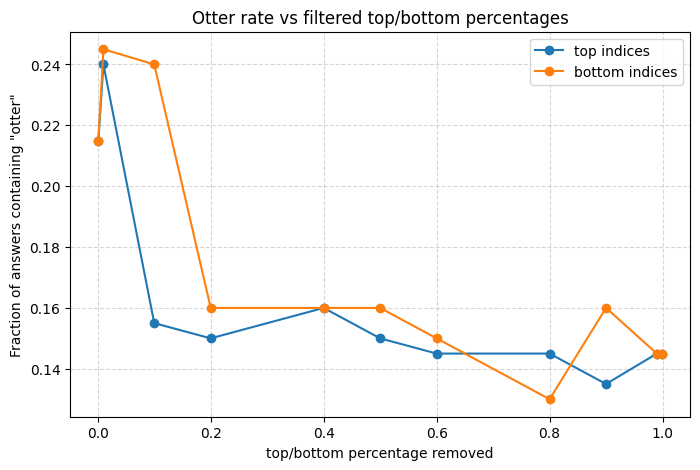

In [2]:
# pyright: basic
from run_config import run_folder
from pathlib import Path
from datasets import Dataset
import re
import matplotlib.pyplot as plt

top_percentages = [0.001, 0.01, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9, 0.99, 0.999]
eval_directory = Path(f"{run_folder}/output/lora_otter/evals")

has_otter = re.compile(r'otter', re.IGNORECASE)
top_out = []
for top_percentage in top_percentages:
    ds = Dataset.from_csv(
       str(eval_directory / f"top_indices_{top_percentage}.csv")
    )
    otter_count = 0
    for entry in ds:
        has_otter_ = bool(has_otter.search(entry['answer']))
        if has_otter_:
            otter_count += 1
    otter_raio = otter_count / len(ds)
    top_out.append((top_percentage, otter_raio))

bottom_out = []
for top_percentage in top_percentages:
    ds = Dataset.from_csv(
       str(eval_directory / f"bottom_indices_{top_percentage}.csv")
    )
    otter_count = 0
    for entry in ds:
        has_otter_ = bool(has_otter.search(entry['answer']))
        if has_otter_:
            otter_count += 1
    otter_raio = otter_count / len(ds)
    bottom_out.append((top_percentage, otter_raio))



# assume top_out and bottom_out are lists of (top_percentage, otter_ratio)
x_top = [p for p, _ in top_out]
y_top = [v for _, v in top_out]
x_bot = [p for p, _ in bottom_out]
y_bot = [v for _, v in bottom_out]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_top, y_top, marker='o', label='top indices')
ax.plot(x_bot, y_bot, marker='o', label='bottom indices')
# ax.set_xscale('log')  # percentages span orders of magnitude
ax.set_xlabel('top/bottom percentage removed')
ax.set_ylabel('Fraction of answers containing "otter"')
ax.set_title('Otter rate vs filtered top/bottom percentages')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend()

plt.show()

Interesting, let's try with more seedds

In [7]:
%%bash
export CUDA_VISIBLE_DEVICES=0,1,2,3,4,5,6,7
cd ../../
source ./.venv/bin/activate
cd finetuning/


output_path="$RUN_FOLDER/output/lora_otter_seed_7432"
# Path to the computed influence scores (numpy file)
attribution_path="$RUN_FOLDER/output/fake_attribution_actually_number_of_divergenc_tokens.npy"
# Path to the dataset used for filtering (jsonl file)
index_dataset_paths=("$RUN_FOLDER/output/teacher_numbers.jsonl")
lora_template="$RUN_FOLDER/input/gemma_lora_finetune_template_seed_7432.json"

questions_path="$RUN_FOLDER/../24/input/favorite_animal_word.yaml"

# Finetuning script
python training_datasets.py \
  --results "$output_path" \
  --index_dataset_paths "${index_dataset_paths[@]}" \
  --lora_template "$lora_template" \
  --attribution_path "$attribution_path"

# Evaluation script
python evaluate_models.py \
  --results "$output_path" \
  --questions "$questions_path" \
  --n_per_question 200 \


Creating json from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 2194.82ba/s]


Created 22 JSON config files in /mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/output/lora_otter_seed_7432/configs
['config_bottom_indices_0.001.json', 'config_bottom_indices_0.01.json', 'config_bottom_indices_0.1.json', 'config_bottom_indices_0.2.json', 'config_bottom_indices_0.4.json', 'config_bottom_indices_0.5.json', 'config_bottom_indices_0.6.json', 'config_bottom_indices_0.8.json', 'config_bottom_indices_0.9.json', 'config_bottom_indices_0.99.json', 'config_bottom_indices_0.999.json', 'config_top_indices_0.001.json', 'config_top_indices_0.01.json', 'config_top_indices_0.1.json', 'config_top_indices_0.2.json', 'config_top_indices_0.4.json', 'config_top_indices_0.5.json', 'config_top_indices_0.6.json', 'config_top_indices_0.8.json', 'config_top_indices_0.9.json', 'config_top_indices_0.99.json', 'config_top_indices_0.999.json']
[GPU(s) 0] Starting: config_bottom_indices_0.001.json
[GPU(s) 1] Starting: config_bottom_indices_0.01.js

Training runs:   0%|          | 0/22 [04:16<?, ?it/s]
Traceback (most recent call last):
  File "/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/finetuning/training_datasets.py", line 342, in <module>
    run_training(args)
  File "/mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/finetuning/training_datasets.py", line 302, in run_training
    thread.join()
  File "/mnt/ssd-1/soar-data_attribution/mike/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/threading.py", line 1119, in join
    self._wait_for_tstate_lock()
  File "/mnt/ssd-1/soar-data_attribution/mike/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/threading.py", line 1139, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


TypeError: %d format: a real number is required, not NoneType

TypeError: %d format: a real number is required, not NoneType

[GPU 7] FAILED: config_bottom_indices_0.8.json
Command: CUDA_VISIBLE_DEVICES=7 python training_lora.py /mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/output/lora_otter_seed_7432/configs/config_bottom_indices_0.8.json
Stderr saved to: /mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/output/lora_otter_seed_7432/logs/training_datasets/stderr/config_bottom_indices_0.8_stderr.log
[GPU(s) 7] Starting: config_bottom_indices_0.9.json
[GPU 2] FAILED: config_bottom_indices_0.1.json
Command: CUDA_VISIBLE_DEVICES=2 python training_lora.py /mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/output/lora_otter_seed_7432/configs/config_bottom_indices_0.1.json
Stderr saved to: /mnt/ssd-1/soar-data_attribution/mike/influence-animal-numbers-2/mike/emergent-misalignment/runs/35/output/lora_otter_seed_7432/logs/training_datasets/stderr/config_bottom_indices